# Task 3: Prediction of perturbation effect

In [2]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pathlib import Path
import numpy as np
import pandas as pd

import scanpy as sc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from scmlcourse.perturbation import *

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
data_dir = Path("../../data")

### Data Loading


In [ ]:
data_module = DataModule(data_dir/"qced_data.h5ad", n_workers=4, n_top_genes=1000, retain_adata = True)

In [ ]:
print(
    data_module.adata,
    data_module.n_vars,
    data_module.batch_size,
    sep="\n------\n")

View of AnnData object with n_obs × n_vars = 106063 × 1038
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'perturbed_gene', 'perturbed_condition'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hi

## Simplistic Baseline: Small MLP

In [ ]:
mlp_config = dict(
    in_dim=data_module.n_vars,
    out_dim=data_module.n_vars,
    hidden_dims=(data_module.n_vars,)*3,
)
baseline_model = Baseline(mlp_config, lr=0.001)

In [ ]:
from pytorch_lightning.loggers import CSVLogger
log_dir = Path("../logs")
log_dir.mkdir(exist_ok=True)

In [ ]:

train(
    baseline_model,
    data_module,
    max_epochs = 1000,
    patience = 15,
    log_dir = "logs",
    run_name = "baseline",
    seed = 0,
)
import gc
gc.collect()

In [ ]:
in_dim=data_module.n_vars
latent_dim = 512
dropout=0.5
encoder_kwargs = dict(
    hidden_dims=(in_dim, in_dim, latent_dim, latent_dim),
    dropout=dropout
)
decoder_kwargs = dict(
    hidden_dims=(latent_dim+in_dim, in_dim, in_dim, in_dim),
    dropout=dropout
)
cvae = cVAE(in_dim = in_dim, latent_dim=latent_dim, encoder_kwargs = encoder_kwargs, decoder_kwargs = decoder_kwargs, lr=0.001, kl_midpoint=2)


{'hidden_dims': (1038, 1038, 512, 512), 'dropout': 0.5, 'in_dim': 1038, 'out_dim': 512}
1038 1038
1038 1038
1038 512
512 512
{'hidden_dims': (1038, 1038, 512, 512), 'dropout': 0.5, 'in_dim': 1038, 'out_dim': 512}
1038 1038
1038 1038
1038 512
512 512
{'hidden_dims': (1550, 1038, 1038, 1038), 'dropout': 0.5, 'out_dim': 1038, 'in_dim': 1550}


In [ ]:
model, test_scores, logged_dir = train(
    cvae,
    data_module,
    max_epochs = 1000,
    patience = 15,
    log_dir = log_dir,
    run_name = "cvae",
    seed = 0,
)
import gc
gc.collect()

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type    | Params | Mode  | FLOPs
----------------------------------------------------------
0 | module        | MLP     | 7.2 M  | train | 0    
1 | loss          | MSELoss | 0      | train | 0    
2 | mu_encoder    | MLP     | 3.2 M  | train | 0    
3 | sigma_encoder | MLP     | 3.2 M  | train | 0   

Training for max 10 epochs...
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/n

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0r

Epoch 0: 100%|██████████| 923/923 [00:06<00:00, 152.44it/s, v_num=1, train_loss_step=2.970, train_loss_kl_step=8.850, train_loss_mse_x_step=1.920]

...

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 923/923 [00:35<00:00, 26.05it/s, v_num=1, train_loss_step=9.500, train_loss_kl_step=7.670, train_loss_mse_x_step=1.840, val_loss=2.850, val_loss_kl=0.787, val_loss_mse_x=2.060, train_loss_epoch=10.20, train_loss_kl_epoch=8.360, train_loss_mse_x_epoch=1.810]


Restoring states from the checkpoint path at /omics/groups/OE0436/data/ntoulouse/scMLCourse/logs/cvae/version_1/epoch=0-val_loss=1.9325.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /omics/groups/OE0436/data/ntoulouse/scMLCourse/logs/cvae/version_1/epoch=0-val_loss=1.9325.ckpt
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('a

Testing DataLoader 0: 100%|██████████| 37/37 [00:00<00:00, 312.53it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         pearson                    nan
        test_loss                   nan
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


3840

In [ ]:
for batch_idx, batch in enumerate(data_module.test_dataloader()):
    with torch.no_grad():
        fc, loss, pearson = model.predict_fc(batch, batch_idx)
    print(fc, loss, pearson)

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_v

tensor([[    nan, -2.3937,     nan,  ...,     nan, -3.1230,     nan],
        [    nan, -2.1164,     nan,  ..., -2.7893,     nan,     nan],
        [    nan, -1.6731, -4.0421,  ..., -1.5405,     nan,     nan],
        ...,
        [-4.8180, -5.3672, -1.4989,  ...,     nan, -2.9931,     nan],
        [    nan, -0.7934,     nan,  ..., -4.8747,     nan,     nan],
        [    nan, -3.6998,     nan,  ...,     nan,     nan, -7.5145]]) tensor(nan) tensor(nan)
tensor([[    nan, -1.2066, -3.6644,  ..., -5.8318,     nan,     nan],
        [-7.5697, -4.8850,     nan,  ..., -6.5613, -3.9899,     nan],
        [-7.0717, -2.0016, -2.8319,  ..., -5.3339,     nan,     nan],
        ...,
        [    nan, -3.5786,     nan,  ...,     nan, -2.2900,     nan],
        [    nan,  2.7419, -2.7172,  ...,     nan, -1.0943, -2.3706],
        [-4.2092,     nan,  0.5505,  ...,     nan,     nan, -6.4711]]) tensor(nan) tensor(nan)
tensor([[-5.7321,  7.0612,     nan,  ...,     nan,  0.4467, -0.4066],
        [    n

NameError: name 'fc' is not defined

In [ ]:
logs = pd.read_csv(log_dir/"cvae/version_1/metrics.csv")
logs

,epoch,lr-Adam,pearson,step,test_loss,train_loss_epoch,train_loss_kl_epoch,train_loss_kl_step,train_loss_mse_x_epoch,train_loss_mse_x_step,train_loss_step,val_loss,val_loss_kl,val_loss_mse_x
0,NaN,0.00001,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,9,NaN,NaN,NaN,8.303756,NaN,4.875232,5.865064,NaN,NaN,NaN
2,0.0,NaN,NaN,19,NaN,NaN,NaN,8.437916,NaN,4.817547,5.823371,NaN,NaN,NaN
3,0.0,NaN,NaN,29,NaN,NaN,NaN,8.386442,NaN,4.942910,5.942598,NaN,NaN,NaN
4,0.0,NaN,NaN,39,NaN,NaN,NaN,8.242384,NaN,4.680083,5.662599,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,9.0,NaN,NaN,9219,NaN,NaN,NaN,8.079494,NaN,1.823302,9.895435,NaN,NaN,NaN
950,9.0,NaN,NaN,9229,NaN,NaN,NaN,7.666224,NaN,1.841147,9.500387,NaN,NaN,NaN
951,9.0,NaN,NaN,9229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.845486,0.787052,2.059151
952,9.0,NaN,NaN,9229,NaN,10.16911,8.363522,NaN,1.813204,NaN,NaN,NaN,NaN,NaN


In [ ]:
logs.pearson

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
949   NaN
950   NaN
951   NaN
952   NaN
953   NaN
Name: pearson, Length: 954, dtype: float64

<Axes: xlabel='epoch'>

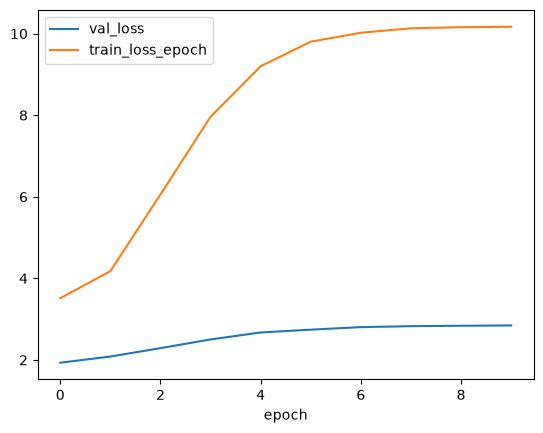

In [ ]:
logs.loc[~(logs["train_loss_epoch"].isna()&logs["val_loss"].isna())].groupby("epoch")[["val_loss", "train_loss_epoch"]].agg(lambda x: x[~x.isna()].iloc[0]).plot()

<Axes: xlabel='epoch'>

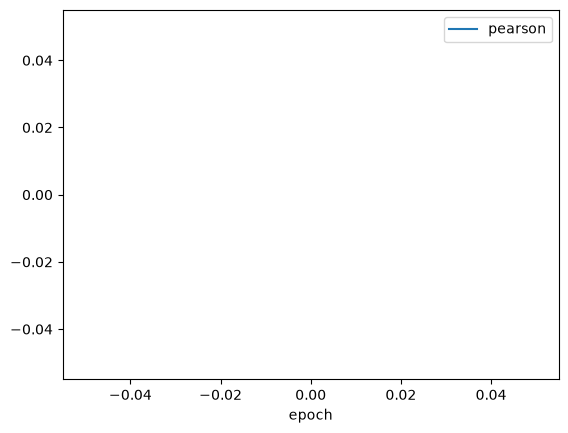

In [ ]:
logs.loc[~(logs["test_loss"].isna()&logs["pearson"].isna())].plot("epoch", "pearson")